#EE470 Fall 2025 Course Project Plant Anomaly Classification Challenge
**Group 3**
* **Mustafa Gökhan Oyanık**
* **Yusuf Erim Bulca**

# Part 1: Downloading the files

*   Download the model and the test data.
*   Apply model to the test data

In [ ]:
!gdown --id 1THog8umKpq_hPN6yBV-r6nNY71f0SRon

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1THog8umKpq_hPN6yBV-r6nNY71f0SRon
From (redirected): https://drive.google.com/uc?id=1THog8umKpq_hPN6yBV-r6nNY71f0SRon&confirm=t&uuid=fbd66c89-6b1d-4e77-9640-0faf825d7d0b
To: /content/modifiedtest.zip
100% 106M/106M [00:00<00:00, 163MB/s] 


In [ ]:
import tensorflow as tf
import zipfile
import os

#Model Public Link ID
MODEL_FILE_ID = '1QkPT36WI8mhi35d7gqhj-ibchyapGJYT'

#Paths
zip_file_path = '/content/modifiedtest.zip'
extract_dir = '/content/test'


#Download Model from Link (No Drive needed)
print(f"Downloading model (ID: {MODEL_FILE_ID})...")
output_model_path = '/content/best_model_downloaded.keras'

if not os.path.exists(output_model_path):
    os.system(f'gdown --id {MODEL_FILE_ID} -O "{output_model_path}"')
    print("Model downloaded successfully!")
else:
    print("Model already exists.")

#Extract Zip
if os.path.exists(zip_file_path):
    if not os.path.exists(extract_dir):
        print("Extracting zip file...")
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Zip extracted successfully.")
    else:
        print("Folder already exists, skipping extraction.")
else:
    print(f"ERROR: '{zip_file_path}' not found!")

#Adjust folder structure
if os.path.exists(extract_dir):
    contents = os.listdir(extract_dir)
    # Check if 'test' subdirectory exists and use it as final_data_path
    if 'test' in contents and os.path.isdir(os.path.join(extract_dir, 'test')):
        final_data_path = os.path.join(extract_dir, 'test')
    elif len(contents) == 1 and os.path.isdir(os.path.join(extract_dir, contents[0])):
        final_data_path = os.path.join(extract_dir, contents[0])
    else:
        final_data_path = extract_dir

    print(f"Test directory: {final_data_path}")


Model downloaded successfully!
Extracting zip file...
Zip extracted successfully.
Test directory: /content/test/test


# Part 2: Start the test

In [ ]:
if os.path.exists(final_data_path):
    if os.path.exists(output_model_path):
        print("Loading model...")
        model = tf.keras.models.load_model(output_model_path)

        test_ds = tf.keras.utils.image_dataset_from_directory(
            final_data_path,
            image_size=(224, 224),
            batch_size=32,
            shuffle=True
        )

        print("\n--- RESULTS ---")
        loss, accuracy = model.evaluate(test_ds)
        print(f"FINAL ACCURACY: {accuracy * 100:.2f}%")
    else:
        print("Test cannot be run because the model file could not be downloaded.")
else:
    print("Process stopped because the zip file is missing or extraction failed.")

Loading model...
Found 10796 files belonging to 16 classes.

--- RESULTS ---
338/338 ━━━━━━━━━━━━━━━━━━━━ 53s 133ms/step - accuracy: 0.8896 - loss: 0.7336
FINAL ACCURACY: 84.83%


#Part 3: Model accuracy based on the classes


*   Figure 1: Confusion Matrix shows the classification performance on the test dataset. Darker blue cells along the diagonal indicate correct predictions.

* Figure 2: Per-class accuracy rates. The model achieves over 80% accuracy in most classes.




Generating predictions for visualization...
338/338 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step


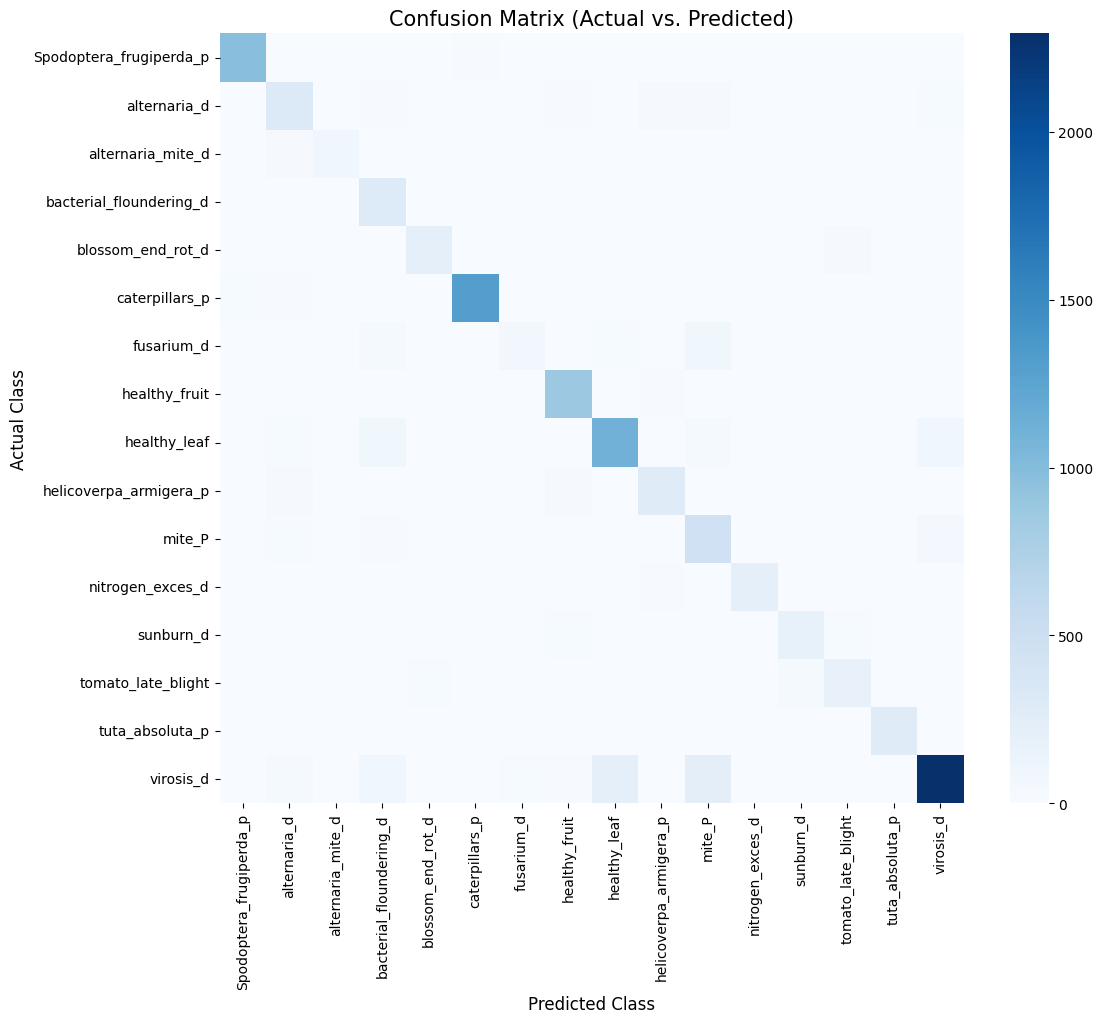

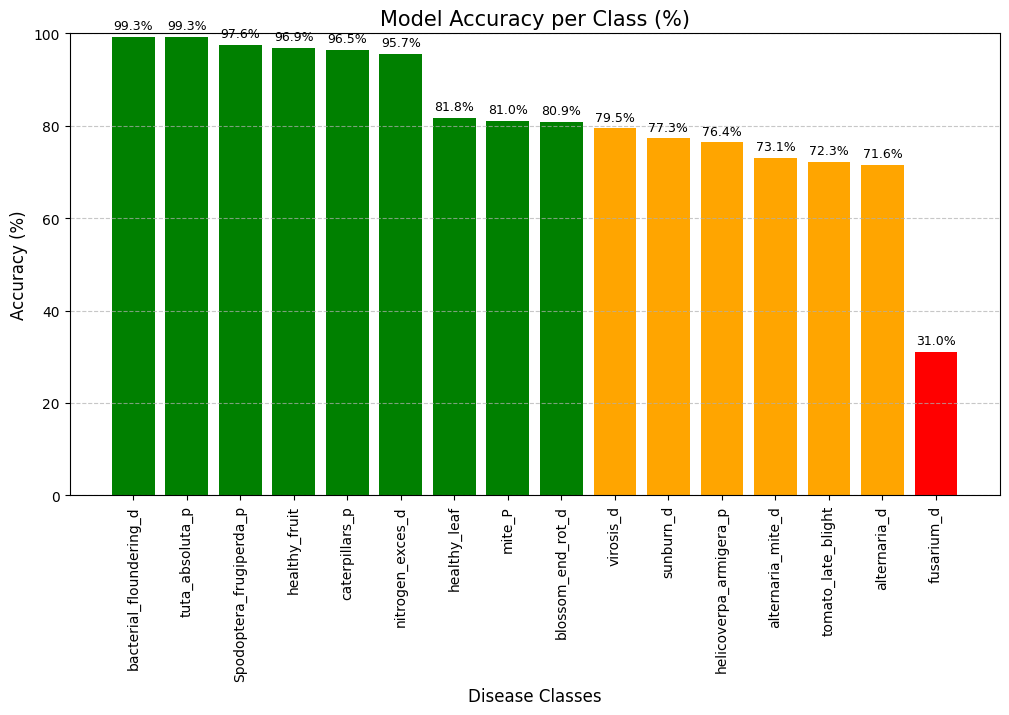

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


# 1. PREPARE DATA
print("Generating predictions for visualization...")

# Get model predictions (probabilities)
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1) # Select class with highest probability
y_true = np.concatenate([y for x, y in test_ds], axis=0) # Get actual labels

# Get class names
class_names = test_ds.class_names


# CHART 1: CONFUSION MATRIX (HEATMAP)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)

# Plotting the Heatmap
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Actual vs. Predicted)', fontsize=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# CHART 2: PER-CLASS ACCURACY (BAR CHART)

# Calculate accuracy for each class
# Diagonal elements divided by the sum of the row
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Handle NaN values if any class has 0 samples
class_accuracies = np.nan_to_num(class_accuracies)

# Sort from highest accuracy to lowest
sorted_indices = np.argsort(class_accuracies)[::-1]
sorted_names = [class_names[i] for i in sorted_indices]
sorted_scores = class_accuracies[sorted_indices] * 100

plt.figure(figsize=(12, 6))

#Color coding: Green (>80%), Orange (>50%), Red (<50%)
colors = ['green' if s > 80 else 'orange' if s > 50 else 'red' for s in sorted_scores]
bars = plt.bar(sorted_names, sorted_scores, color=colors)

plt.title('Model Accuracy per Class (%)', fontsize=15)
plt.xlabel('Disease Classes', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{round(yval, 1)}%', ha='center', va='bottom', fontsize=9)

plt.show()